# Segmentation

Goal of this notebook: Build a segmentation model to segment the people represented in the dataset, for potential downstream marketing campaign planning.

Major sections:

1. Feature selection & engineering (different from classification)
2. Selection of K for K-means algorithm
3. Build K-means model based on selected k
4. Segmentation result analysis
5. PCA & Segmentation cohorts visualization


Refer to Reports.pdf and decisions.md for detailed findings and decision making process.

In [12]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 200)

DATA_DIR = Path("../data")
REPORTS_DIR = Path("../reports")
SEED = 42

In [13]:
df = pd.read_parquet(DATA_DIR / "df_loaded.parquet")
print(df.shape)
print(df[["age", "education", "weeks worked in year", "weight", "y"]].head())

(199523, 43)
   age                   education  weeks worked in year   weight  y
0   73        High school graduate                     0  1700.09  0
1   58  Some college but no degree                    52  1053.55  0
2   18                  10th grade                     0   991.95  0
3    9                    Children                     0  1758.14  0
4   10                    Children                     0  1069.16  0


### Feature Selection & Engineering

In [14]:
# Education ordinal (same mapping as preprocessing)
education_order = {
    "Children": 0,
    "Less than 1st grade": 1,
    "1st 2nd 3rd or 4th grade": 2,
    "5th or 6th grade": 3,
    "7th and 8th grade": 4,
    "9th grade": 5,
    "10th grade": 6,
    "11th grade": 7,
    "12th grade no diploma": 8,
    "High school graduate": 9,
    "Some college but no degree": 10,
    "Associates degree-occup /vocational": 11,
    "Associates degree-academic program": 11,
    "Bachelors degree(BA AB BS)": 12,
    "Masters degree(MA MS MEng MEd MSW MBA)": 13,
    "Prof school degree (MD DDS DVM LLB JD)": 14,
    "Doctorate degree(PhD EdD)": 15,
}
df["education_ordinal"] = df["education"].map(education_order)

# Demographic/lifestyle flags
df["is_employed"]         = (df["weeks worked in year"] > 0).astype(int)
df["is_self_employed"]    = df["class of worker"].str.contains("Self-employed", case=False, na=False).astype(int)
df["married_joint_filer"] = df["tax filer stat"].str.contains("Joint", case=False, na=False).astype(int)
df["is_male"]             = (df["sex"] == "Male").astype(int)

In [15]:
continuous_cols = ["age", "education_ordinal", "weeks worked in year"]
binary_cols     = ["is_employed", "is_self_employed", "married_joint_filer", "is_male"]

scaler = StandardScaler()
X_cont = scaler.fit_transform(df[continuous_cols])
X_bin  = df[binary_cols].to_numpy(dtype=float)

X_cluster = np.hstack([X_cont, X_bin])
feature_names = continuous_cols + binary_cols
print(f"Cluster matrix: {X_cluster.shape}, features: {feature_names}")

Cluster matrix: (199523, 7), features: ['age', 'education_ordinal', 'weeks worked in year', 'is_employed', 'is_self_employed', 'married_joint_filer', 'is_male']


### Selecting K for K-means

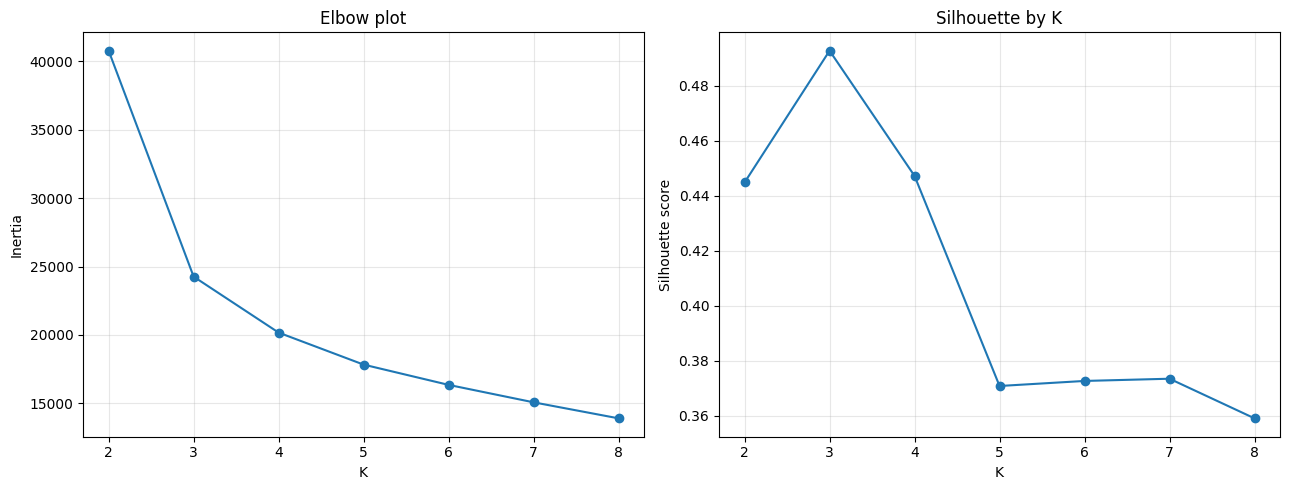

Silhouettes: {2: 0.445, 3: 0.493, 4: 0.447, 5: 0.371, 6: 0.373, 7: 0.373, 8: 0.359}


In [16]:
rng = np.random.RandomState(SEED)
sample_idx = rng.choice(len(X_cluster), size=min(20_000, len(X_cluster)), replace=False)
X_sample = X_cluster[sample_idx]

K_range = range(2, 9)
inertias, silhouettes = [], []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    km.fit(X_sample)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_sample, km.predict(X_sample)))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(list(K_range), inertias, marker="o")
axes[0].set_xlabel("K"); axes[0].set_ylabel("Inertia"); axes[0].set_title("Elbow plot")
axes[0].grid(alpha=0.3)

axes[1].plot(list(K_range), silhouettes, marker="o")
axes[1].set_xlabel("K"); axes[1].set_ylabel("Silhouette score"); axes[1].set_title("Silhouette by K")
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig(REPORTS_DIR / "k_selection.png", dpi=150, bbox_inches="tight")
plt.show()

print("Silhouettes:", dict(zip(K_range, [round(s, 3) for s in silhouettes])))

### Build the K-means segmentation model

In [17]:
K = 4 

weights = df["weight"].to_numpy()
kmeans = KMeans(n_clusters=K, random_state=SEED, n_init=20)
df["segment"] = kmeans.fit_predict(X_cluster, sample_weight=weights)

print("Segment sizes (sample):")
print(df["segment"].value_counts().sort_index())
print("\nSegment sizes (population-weighted share):")
print((df.groupby("segment")["weight"].sum() / df["weight"].sum()).round(3))

Segment sizes (sample):
segment
0    28923
1    89126
2    32111
3    49363
Name: count, dtype: int64

Segment sizes (population-weighted share):
segment
0    0.151
1    0.454
2    0.158
3    0.237
Name: weight, dtype: float64


### Segmentation result analysis

In [18]:
profile_cols = continuous_cols + binary_cols + ["y"]

def weighted_mean(s, w):
    return (s * w).sum() / w.sum()

profile_rows = []
for seg in sorted(df["segment"].unique()):
    g = df[df["segment"] == seg]
    w = g["weight"]
    row = {"segment": seg, "n_sample": len(g), "pop_share": w.sum() / df["weight"].sum()}
    for col in profile_cols:
        row[col] = weighted_mean(g[col], w)
    profile_rows.append(row)

profile = pd.DataFrame(profile_rows).set_index("segment")

# Add population baselines for comparison
baseline = {col: weighted_mean(df[col], df["weight"]) for col in profile_cols}
profile.loc["POPULATION"] = {
    "n_sample": len(df),
    "pop_share": 1.0,
    **baseline,
}

print(profile.round(3))
profile.round(3).to_csv(REPORTS_DIR / "segment_profile.csv")

            n_sample  pop_share     age  education_ordinal  weeks worked in year  is_employed  is_self_employed  married_joint_filer  is_male      y
segment                                                                                                                                             
0              28923      0.151  26.527              8.229                 6.220        0.415             0.023                0.268    0.390  0.003
1              89126      0.454  39.410              9.907                49.528        1.000             0.116                0.614    0.545  0.133
2              32111      0.158  68.575              7.974                 0.946        0.074             0.013                0.468    0.380  0.021
3              49363      0.237   7.400              0.137                 0.022        0.001             0.000                0.002    0.513  0.000
POPULATION    199523      1.000  34.474              7.029                23.582        0.529             

In [19]:
crosstab_rows = []
total_w = df["weight"].sum()
total_pos_w = (df["weight"] * df["y"]).sum()

for seg in sorted(df["segment"].unique()):
    g = df[df["segment"] == seg]
    w_sum = g["weight"].sum()
    pos_w = (g["weight"] * g["y"]).sum()
    crosstab_rows.append({
        "segment": seg,
        "pop_share": w_sum / total_w,
        "high_income_rate": pos_w / w_sum,
        "share_of_high_income": pos_w / total_pos_w,
        "targeting_efficiency": (pos_w / total_pos_w) / (w_sum / total_w),
    })

crosstab = pd.DataFrame(crosstab_rows).set_index("segment").round(3)
print(crosstab)
crosstab.to_csv(REPORTS_DIR / "segment_marketing_table.csv")

         pop_share  high_income_rate  share_of_high_income  targeting_efficiency
segment                                                                         
0            0.151             0.003                 0.007                 0.050
1            0.454             0.133                 0.940                 2.070
2            0.158             0.021                 0.052                 0.331
3            0.237             0.000                 0.000                 0.000


### PCA & Segmentation visualization

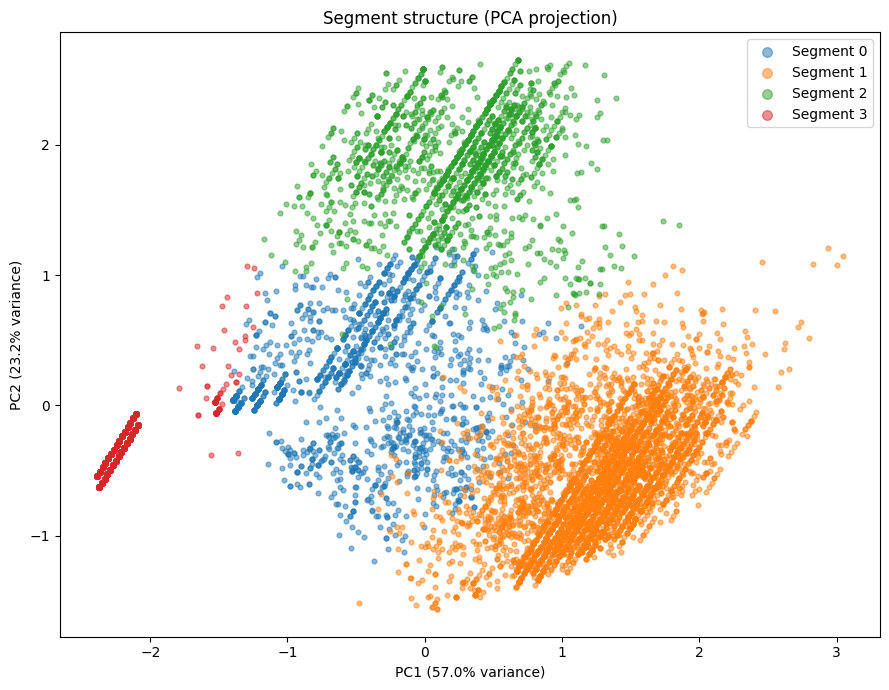

In [20]:
plot_n = min(10_000, len(df))
plot_idx = rng.choice(len(X_cluster), size=plot_n, replace=False)
X_plot   = X_cluster[plot_idx]
labels_plot = df["segment"].iloc[plot_idx].to_numpy()

pca = PCA(n_components=2, random_state=SEED)
X_pca = pca.fit_transform(X_plot)

plt.figure(figsize=(9, 7))
cmap = plt.cm.tab10
for seg in sorted(df["segment"].unique()):
    mask = labels_plot == seg
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                s=12, alpha=0.5, color=cmap(seg), label=f"Segment {seg}")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)")
plt.title("Segment structure (PCA projection)")
plt.legend(markerscale=2)
plt.tight_layout()
plt.savefig(REPORTS_DIR / "segment_pca.png", dpi=150, bbox_inches="tight")
plt.show()

In [21]:
persona_names = {
    0: "Early Career/Students",
    1: "Experienced Professionals",
    2: "Retirees",
    3: "Children/Minors"
}

summary = crosstab.copy()
summary["persona"] = summary.index.map(persona_names)
summary = summary[["persona", "pop_share", "high_income_rate", "share_of_high_income", "targeting_efficiency"]]
print(summary)
summary.to_csv(REPORTS_DIR / "segment_personas.csv")

                           persona  pop_share  high_income_rate  share_of_high_income  targeting_efficiency
segment                                                                                                    
0            Early Career/Students      0.151             0.003                 0.007                 0.050
1        Experienced Professionals      0.454             0.133                 0.940                 2.070
2                         Retirees      0.158             0.021                 0.052                 0.331
3                  Children/Minors      0.237             0.000                 0.000                 0.000


In [22]:
df[["segment"]].to_parquet(DATA_DIR / "segments.parquet")
joblib.dump(kmeans, DATA_DIR / "kmeans_model.joblib")
joblib.dump(scaler, DATA_DIR / "cluster_scaler.joblib")
print("Segmentation saved.")

Segmentation saved.
